In [7]:
import os
from typing import TypedDict, List, Dict
import json, re

from langgraph.graph import StateGraph, END, START
from langchain_openrouter import ChatOpenRouter
from langchain_core.messages import SystemMessage, HumanMessage
from tavily import TavilyClient

llm = ChatOpenRouter(
    model="nvidia/nemotron-3-super-120b-a12b:free",
    temperature=0,
    max_tokens=4096,
    max_retries=2,
    streaming=False,
)

os.environ["TAVILY_PROJECT"] = "restaurant_recommender_agent"
tavily = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

In [2]:
# Shared State
class AgentState(TypedDict):
    food: str                  
    location: str              
    restaurants: List[Dict]    
    comparison: str

In [ ]:
# Agent 1: Scout  (find restaurants + gather their reviews)
def scout_agent(state: AgentState) -> AgentState:
    """
    Find 5 relevant restaurants, then pull review evidence for each
    """
    # Step 1: discover candidates
    discovery_query = f"best {state['food']} restaurants in {state['location']} with reviews"
    raw = tavily.search(query=discovery_query, search_depth="advanced", max_results=8)
    context = "\n".join(
        f"- {r.get('title', '')}: {r.get('content', '')[:400]} (source: {r.get('url', '')})"
        for r in raw.get("results", [])
    )

    prompt = [
        SystemMessage(content=(
            "You extract a clean list of restaurants from raw web search results. "
            "Pick the most relevant, real restaurants for the user's request."
            "Respond with ONLY a JSON array of {name, short_description} objects."
        )),
        HumanMessage(content=(
            f"User wants: {state['food']} in {state['location']}.\n\n"
            f"Search results:\n{context}\n\n"
            "Pick the 5 most relevant, real restaurants."
        )),
    ]
    result = llm.invoke(prompt).content
    match = re.search(r"\[.*\]", result, re.DOTALL)
    try:
        restaurants = json.loads(match.group())[:5] if match else []
    except (json.JSONDecodeError, AttributeError):
        restaurants = []

    print(f"Found {len(restaurants)} candidate restaurants.\n")

    # Step 2: gather reviews for each pick
    for r in restaurants:
        name = r["name"]
        res = tavily.search(
            query=f"{name} {state['location']} customer reviews ratings",
            search_depth="basic",
            max_results=4,
        )
        r["reviews"] = "\n".join(
            item.get("content", "")[:500] for item in res.get("results", [])
        ) or "No review data found."
        print(f"Gathered reviews for: {name}")
    print()

    return {**state, "restaurants": restaurants}


# Agent 2: Critic  (fair comparison)
def critic_agent(state: AgentState) -> AgentState:
    """Synthesize a balanced comparison from the gathered review evidence."""
    review_block = "\n\n".join(
        f"### {r['name']}\n{r.get('reviews', 'No data.')}" for r in state["restaurants"]
    )

    prompt = [
        SystemMessage(content=(
            """You are a fair, unbiased food critic. Compare the restaurants using
            ONLY the review evidence provided — never invent ratings, prices, or details not supported by the text.
            For EACH restaurant, write these four labeled sections:
            • **What reviews are saying** — the recurring themes in the reviews,
            both positive and negative.
            • **Perceived value for money** — what the reviews suggest about price vs. quality. 
            If reviews don't mention price/value, say so plainly.
            • **Service & atmosphere** — what reviews say about staff, service speed, and ambiance.
            • **Best for** — the type of diner or occasion this place suits, based on the evidence.
            After covering all restaurants, end with a short **Note on evidence**
            that flags any restaurants where the review data was thin or sparse,
            so the reader knows where the comparison is less reliable."""
        )),
        HumanMessage(content=(
            f"User wanted: {state['food']} in {state['location']}.\n\n"
            f"Review evidence:\n{review_block}\n\n"
            "Produce a clear, fair and structured comparison as instructed."
        )),
    ]
    return {**state, "comparison": llm.invoke(prompt).content}

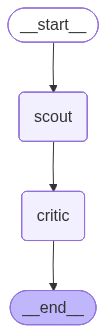

In [4]:
# Build the Graph
def build_graph():
    g = StateGraph(AgentState)
    g.add_node("scout", scout_agent)
    g.add_node("critic", critic_agent)

    g.add_edge(START, "scout")
    g.add_edge("scout", "critic")
    g.add_edge("critic", END)
    return g.compile()

app = build_graph()
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
food = input("What would you like to eat? (cuisine/dish): ").strip()
location = input("Where? (city/area): ").strip()
print(f"\nLooking for '{food}' restaurants in '{location}'...\n")

final = app.invoke({
    "food": food,
    "location": location,
    "restaurants": [],
    "comparison": "",
})

print("\n" + "=" * 70)
print("RESTAURANT COMPARISON")
print("=" * 70 + "\n")
print(final["comparison"])

Found 5 candidate restaurants.

Gathered reviews for: Bettola
Gathered reviews for: The Essential
Gathered reviews for: EastWest
Gathered reviews for: Juniper
Gathered reviews for: Croixstreet Vegan


RESTAURANT COMPARISON

**Comparison of Birmingham‑area restaurants for a vegetarian‑pasta dish (based solely on the supplied review excerpts)**  

| Restaurant | What the reviews say about food (relevant to pasta/veg) | Service / Atmosphere | Evidence strength for veg‑pasta claim | Notable strengths | Notable weaknesses |
|------------|----------------------------------------------------------|----------------------|----------------------------------------|-------------------|--------------------|
| **Bettola** | Described as “good very contemporary Italian” and “food was alright.” No explicit mention of pasta or vegetarian options, but the Italian focus suggests pasta is likely on the menu. | Service called “the worst … I’ve had in Birmingham” (hour‑long wait to place order); ambiance no